# Sales Data Analysis

## 1. Imports

In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings
import pyarrow as pa
import os
from datetime import datetime
import pyarrow.parquet as pq
from typing import Optional
warnings.filterwarnings('ignore')


pd.set_option('display.max_columns', 100)

## 2. Info

In [4]:
# import pandas as pd
# import pyarrow as pa
# import pyarrow.parquet as pq
# import os

# INPUT_CSV   = '../data/generated/sales_data.csv'
# OUTPUT_FILE = '../data/generated/sales_data.parquet'
# CHUNK_SIZE  = 100_000

# # ── Explicit schema — pins holiday_name (and any other mixed column) as string ──
# SCHEMA = pa.schema([
#     ("date",                    pa.large_utf8()),
#     ("region",                  pa.large_utf8()),
#     ("city",                    pa.large_utf8()),
#     ("store",                   pa.large_utf8()),
#     ("store_id",                pa.int64()),
#     ("product",                 pa.large_utf8()),
#     ("brand",                   pa.large_utf8()),
#     ("category",                pa.large_utf8()),
#     ("price",                   pa.int64()),
#     ("discount",                pa.int64()),
#     ("final_price",             pa.float64()),
#     ("inventory",               pa.int64()),
#     ("demand",                  pa.int64()),
#     ("sales_qty",               pa.int64()),
#     ("sales",                   pa.float64()),
#     ("in_mall",                 pa.int64()),
#     ("store_size_sqft",         pa.int64()),
#     ("local_competitor_count",  pa.int64()),
#     ("foot_traffic_index",      pa.int64()),
#     ("parking_available",       pa.int64()),
#     ("store_age_years",         pa.int64()),
#     ("online_pickup_point",     pa.int64()),
#     ("population_density",      pa.int64()),
#     ("gdp_per_capita",          pa.int64()),
#     ("mall_count",              pa.int64()),
#     ("is_metro",                pa.int64()),
#     ("is_weekend",              pa.int64()),
#     ("is_holiday",              pa.int64()),
#     ("holiday_name",            pa.large_utf8()),   # ← was flipping to double
#     ("year_factor",             pa.float64()),
#     ("weekend_boost",           pa.float64()),
#     ("festival_boost",          pa.float64()),
#     ("holiday_boost",           pa.float64()),
#     ("stockout_flag",           pa.int64()),
#     ("lost_sales",              pa.int64()),
#     ("is_promo_campaign",       pa.int64()),
#     ("promo_type",              pa.large_utf8()),
#     ("marketing_spend",         pa.int64()),
#     ("temperature",             pa.float64()),
#     ("rainfall_mm",             pa.float64()),
#     ("humidity_pct",            pa.int64()),
#     ("weather_condition",       pa.large_utf8()),
#     ("weather_demand_mod",      pa.float64()),
#     ("is_month_start",          pa.int64()),
#     ("is_month_end",            pa.int64()),
#     ("salary_week_flag",        pa.int64()),
#     ("supplier_lead_time_days", pa.int64()),
#     ("reorder_point",           pa.int64()),
#     ("area_type",               pa.large_utf8()),
#     ("premium_store_flag",      pa.int64()),
#     ("student_area_flag",       pa.int64()),
#     ("office_area_flag",        pa.int64()),
#     ("avg_basket_size",         pa.int64()),
#     ("competitor_price_index",  pa.float64()),
#     ("festival_intensity_score",pa.int64()),
# ])

# writer = None
# total_rows = 0

# try:
#     for i, chunk in enumerate(pd.read_csv(INPUT_CSV,
#                                            chunksize=CHUNK_SIZE,
#                                            engine='python',
#                                            dtype={"holiday_name": "str"})):  # force str on read

#         # Fill NaN in string columns so Arrow doesn't see float nulls
#         for col in ["holiday_name", "promo_type", "area_type",
#                     "weather_condition", "region", "city", "store",
#                     "product", "brand", "category"]:
#             chunk[col] = chunk[col].fillna("").astype(str)

#         table = pa.Table.from_pandas(chunk, schema=SCHEMA, preserve_index=False)

#         if writer is None:
#             writer = pq.ParquetWriter(OUTPUT_FILE, SCHEMA, compression='snappy')

#         writer.write_table(table)
#         total_rows += len(chunk)
#         print(f"  chunk {i+1:>4}  |  rows written so far: {total_rows:,}")

# finally:
#     if writer:
#         writer.close()

# if os.path.exists(OUTPUT_FILE):
#     meta = pq.read_metadata(OUTPUT_FILE)
#     size_mb = os.path.getsize(OUTPUT_FILE) / 1_048_576
#     print(f"\n✓ Parquet written → {OUTPUT_FILE}")
#     print(f"  rows      : {meta.num_rows:,}")
#     print(f"  row groups: {meta.num_row_groups}")
#     print(f"  file size : {size_mb:.1f} MB")

In [6]:
sales_df = pd.read_parquet("../data/generated/sales_data.parquet", engine='pyarrow')

In [7]:
availability_df = pd.read_csv("../data/generated/availability.csv", engine = 'python')
cities_df = pd.read_csv("../data/generated/cities.csv", engine = 'python')
products_df = pd.read_csv("../data/generated/products.csv", engine = 'python')
regions_df = pd.read_csv("../data/generated/regions.csv", engine = 'python') 
stores_df = pd.read_csv("../data/generated/stores.csv", engine = 'python')

### 1. Master Data

In [18]:
# Availability Dataframe
availability_df.head()

,product_id,region
0,1,Maharashtra
1,1,Kerala
2,1,Karnataka
3,1,Delhi
4,1,Gujarat


In [19]:
availability_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   product_id  120 non-null    int64
 1   region      120 non-null    str  
dtypes: int64(1), str(1)
memory usage: 2.9 KB


In [20]:
# Cities df
cities_df.head()

,city_id,city,region,population_density,gdp_per_capita,mall_count,is_metro
0,1,Mumbai,Maharashtra,20000,210000,24,1
1,2,Pune,Maharashtra,8000,180000,14,1
2,3,Nagpur,Maharashtra,4000,120000,6,0
3,4,Kochi,Kerala,5800,160000,9,1
4,5,Trivandrum,Kerala,4800,150000,7,0


In [21]:
cities_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   city_id             12 non-null     int64
 1   city                12 non-null     str  
 2   region              12 non-null     str  
 3   population_density  12 non-null     int64
 4   gdp_per_capita      12 non-null     int64
 5   mall_count          12 non-null     int64
 6   is_metro            12 non-null     int64
dtypes: int64(5), str(2)
memory usage: 992.0 bytes


In [22]:
#n products df
products_df.head()

,product_id,product,brand,category
0,1,Samsung Electronics 1,Samsung,Electronics
1,2,Samsung Electronics 2,Samsung,Electronics
2,3,Samsung Electronics 3,Samsung,Electronics
3,4,Sony Electronics 1,Sony,Electronics
4,5,Sony Electronics 2,Sony,Electronics


In [23]:
products_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   product_id  27 non-null     int64
 1   product     27 non-null     str  
 2   brand       27 non-null     str  
 3   category    27 non-null     str  
dtypes: int64(1), str(3)
memory usage: 1.7 KB


In [24]:
# regions df
regions_df.head()

,region_id,region
0,1,Maharashtra
1,2,Kerala
2,3,Karnataka
3,4,Tamil Nadu
4,5,Delhi


In [25]:
regions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   region_id  6 non-null      int64
 1   region     6 non-null      str  
dtypes: int64(1), str(1)
memory usage: 276.0 bytes


In [26]:
# Stores df
stores_df.head()

,store_id,store,city,region,in_mall,store_size_sqft,local_competitor_count,foot_traffic_index,parking_available,store_age_years,online_pickup_point,area_type,premium_store_flag,student_area_flag,office_area_flag,avg_basket_size,supplier_lead_time_days,reorder_point
0,1,Bandra Hub,Mumbai,Maharashtra,0,3592,4,52,1,11,0,student,0,1,0,604,2,18
1,2,Borivali Plaza,Mumbai,Maharashtra,0,2015,4,61,1,12,0,residential,0,0,0,1627,1,14
2,3,Dadar Central,Mumbai,Maharashtra,1,5747,5,91,1,9,1,student,1,1,0,698,1,11
3,4,Andheri Mart,Mumbai,Maharashtra,1,3600,6,93,1,9,1,residential,0,0,0,709,3,33
4,5,Kothrud Market,Pune,Maharashtra,0,2455,2,33,1,14,0,commercial,0,0,0,1442,2,28


In [27]:
stores_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   store_id                 37 non-null     int64
 1   store                    37 non-null     str  
 2   city                     37 non-null     str  
 3   region                   37 non-null     str  
 4   in_mall                  37 non-null     int64
 5   store_size_sqft          37 non-null     int64
 6   local_competitor_count   37 non-null     int64
 7   foot_traffic_index       37 non-null     int64
 8   parking_available        37 non-null     int64
 9   store_age_years          37 non-null     int64
 10  online_pickup_point      37 non-null     int64
 11  area_type                37 non-null     str  
 12  premium_store_flag       37 non-null     int64
 13  student_area_flag        37 non-null     int64
 14  office_area_flag         37 non-null     int64
 15  avg_basket_size    

### 2. Sales Dataframe

In [28]:
sales_df.head()

,date,region,city,store,store_id,product,brand,category,price,discount,final_price,inventory,demand,sales_qty,sales,in_mall,store_size_sqft,local_competitor_count,foot_traffic_index,parking_available,store_age_years,online_pickup_point,population_density,gdp_per_capita,mall_count,is_metro,is_weekend,is_holiday,holiday_name,year_factor,weekend_boost,festival_boost,holiday_boost,stockout_flag,lost_sales,is_promo_campaign,promo_type,marketing_spend,temperature,rainfall_mm,humidity_pct,weather_condition,weather_demand_mod,is_month_start,is_month_end,salary_week_flag,supplier_lead_time_days,reorder_point,area_type,premium_store_flag,student_area_flag,office_area_flag,avg_basket_size,competitor_price_index,festival_intensity_score
0,2016-01-01,Maharashtra,Mumbai,Bandra Hub,1,Samsung Electronics 1,Samsung,Electronics,29429,10,26486.10,12,11,11,291347.10,0,3592,4,52,1,11,0,20000,210000,24,1,0,0,,1.0,1.0,1.0,1.0,0,0,0,,0,28.3,0.0,57,Sunny,1.0,1,0,1,2,18,student,0,1,0,604,1.1270,0
1,2016-01-01,Maharashtra,Mumbai,Bandra Hub,1,Samsung Electronics 2,Samsung,Electronics,46485,5,44160.75,39,33,33,1457304.75,0,3592,4,52,1,11,0,20000,210000,24,1,0,0,,1.0,1.0,1.0,1.0,0,0,0,,0,28.3,0.0,57,Sunny,1.0,1,0,1,2,18,student,0,1,0,604,1.0995,0
2,2016-01-01,Maharashtra,Mumbai,Bandra Hub,1,Samsung Electronics 3,Samsung,Electronics,27684,0,27684.00,49,34,34,941256.00,0,3592,4,52,1,11,0,20000,210000,24,1,0,0,,1.0,1.0,1.0,1.0,0,0,0,,0,28.3,0.0,57,Sunny,1.0,1,0,1,2,18,student,0,1,0,604,1.1278,0
3,2016-01-01,Maharashtra,Mumbai,Bandra Hub,1,Sony Electronics 2,Sony,Electronics,57529,5,54652.55,25,23,23,1257008.65,0,3592,4,52,1,11,0,20000,210000,24,1,0,0,,1.0,1.0,1.0,1.0,0,0,0,,0,28.3,0.0,57,Sunny,1.0,1,0,1,2,18,student,0,1,0,604,1.1190,0
4,2016-01-01,Maharashtra,Mumbai,Bandra Hub,1,LG Electronics 1,LG,Electronics,32991,10,29691.90,18,15,15,445378.50,0,3592,4,52,1,11,0,20000,210000,24,1,0,0,,1.0,1.0,1.0,1.0,0,0,0,,0,28.3,0.0,57,Sunny,1.0,1,0,1,2,18,student,0,1,0,604,1.1269,0


In [29]:
sales_df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
store_id,2883231.0,18.912281,10.540797,1.000,10.0000,19.0000,28.0000,3.700000e+01
price,2883231.0,14345.633460,19263.471692,50.000,394.0000,3022.0000,29758.0000,5.999900e+04
discount,2883231.0,6.495553,6.724564,0.000,0.0000,5.0000,10.0000,2.000000e+01
final_price,2883231.0,13413.885444,18083.678250,40.000,366.3000,2811.6000,27682.2000,5.999900e+04
inventory,2883231.0,67.766690,75.447885,0.000,20.0000,41.0000,88.0000,1.331000e+03
demand,2883231.0,59.362653,63.806606,1.000,18.0000,36.0000,77.0000,9.470000e+02
sales_qty,2883231.0,57.518980,62.171090,0.000,18.0000,35.0000,75.0000,9.470000e+02
sales,2883231.0,291147.249730,489040.417147,0.000,30456.0000,87908.2500,352276.1500,1.378727e+07
in_mall,2883231.0,0.415655,0.492835,0.000,0.0000,0.0000,1.0000,1.000000e+00
store_size_sqft,2883231.0,4246.635628,2807.382258,700.000,1908.0000,3600.0000,6261.0000,9.799000e+03


In [30]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2883231 entries, 0 to 2883230
Data columns (total 55 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   date                      str    
 1   region                    str    
 2   city                      str    
 3   store                     str    
 4   store_id                  int64  
 5   product                   str    
 6   brand                     str    
 7   category                  str    
 8   price                     int64  
 9   discount                  int64  
 10  final_price               float64
 11  inventory                 int64  
 12  demand                    int64  
 13  sales_qty                 int64  
 14  sales                     float64
 15  in_mall                   int64  
 16  store_size_sqft           int64  
 17  local_competitor_count    int64  
 18  foot_traffic_index        int64  
 19  parking_available         int64  
 20  store_age_years           int64  
 

## 3. Master Data Analysis

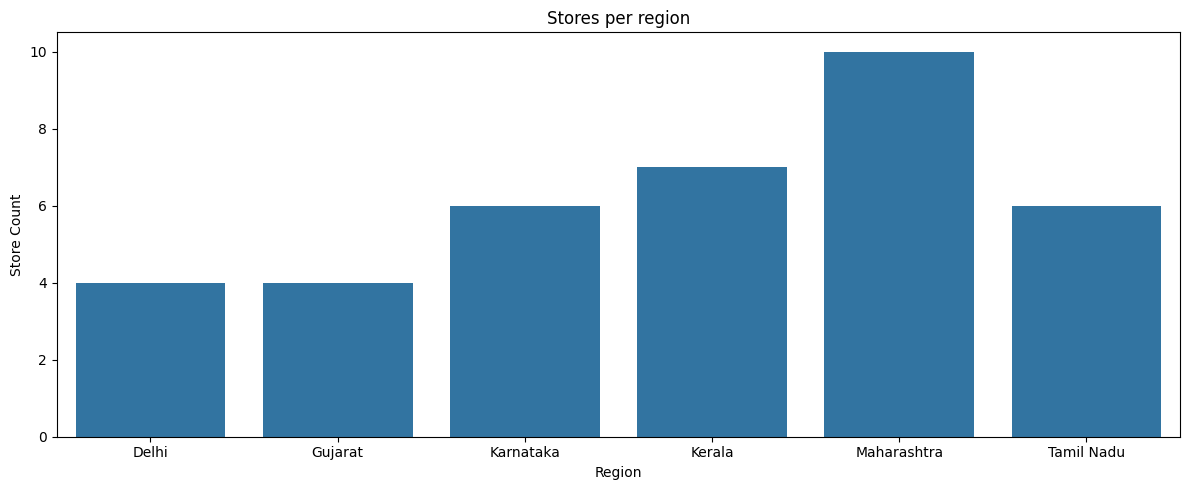

In [32]:
# Stores per region
stores_per_region = stores_df.groupby('region')['store_id'].nunique().reset_index()

# Plot
from helper_functions import plot_bar_chart
fig = plot_bar_chart(
    stores_per_region,
    "region",
    "store_id",
    "Stores per region",
    "Region",
    "Store Count"
)

In [33]:
from helper_functions import metro_city_dictionary
# Stores in metro v/s non metro cities
stores_per_city_type = stores_df.groupby("city")["store_id"].nunique().reset_index()
stores_per_city_type["is_metro"] = stores_per_city_type["city"].map(metro_city_dictionary)
stores_per_city_type

,city,store_id,is_metro
0,Ahmedabad,2,0
1,Bangalore,4,1
2,Chennai,2,1
3,Coimbatore,4,0
4,Kochi,4,0
5,Mumbai,4,1
6,Mysore,2,0
7,Nagpur,4,0
8,New Delhi,4,1
9,Pune,2,0


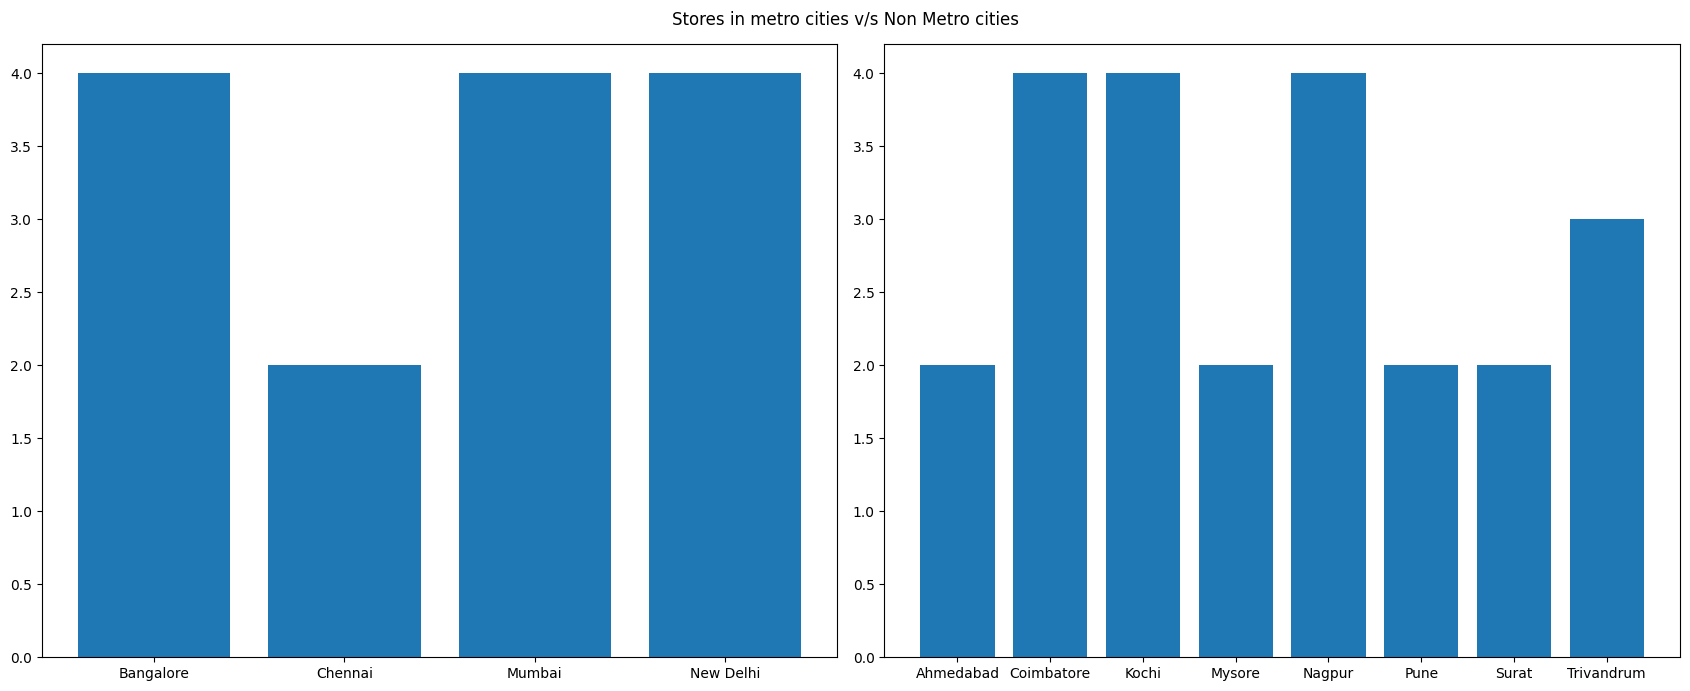

In [34]:
fig, ax = plt.subplots(figsize = (17, 7), ncols = 2)

fig.suptitle("Stores in metro cities v/s Non Metro cities")

ax[0].bar(stores_per_city_type[stores_per_city_type['is_metro'] == 1]['city'], stores_per_city_type[stores_per_city_type['is_metro'] ==1]['store_id'])

ax[1].bar(stores_per_city_type[stores_per_city_type['is_metro'] == 0]['city'], stores_per_city_type[stores_per_city_type['is_metro'] ==0]['store_id'])

plt.tight_layout()
fig.show()

In [36]:
# Store Size Analysis

# Avg Store size
avg_store_size = stores_df['store_size_sqft'].mean()
print(f"Average store size: {round(avg_store_size, 2)} sqft")

Average store size: 4160.46 sqft


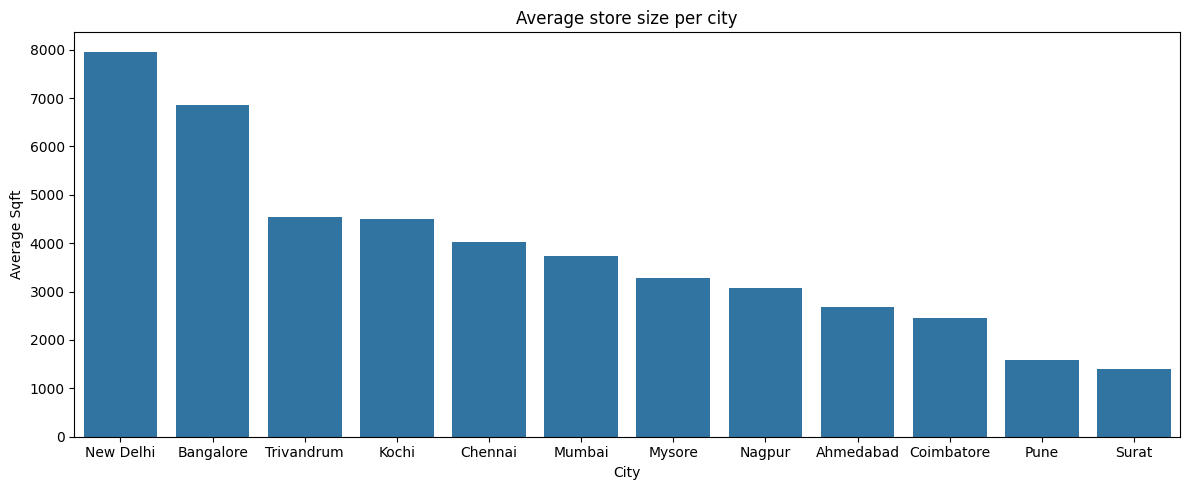

In [37]:
# Average store size per cities
store_size_per_city = stores_df.groupby('city')['store_size_sqft'].mean().reset_index().sort_values(by = 'store_size_sqft', ascending= False)

fig = plot_bar_chart(
    df = store_size_per_city, 
    x_col = "city", 
    y_col = "store_size_sqft", 
    title = "Average store size per city", 
    x_label = "City", 
    y_label = "Average Sqft"
)

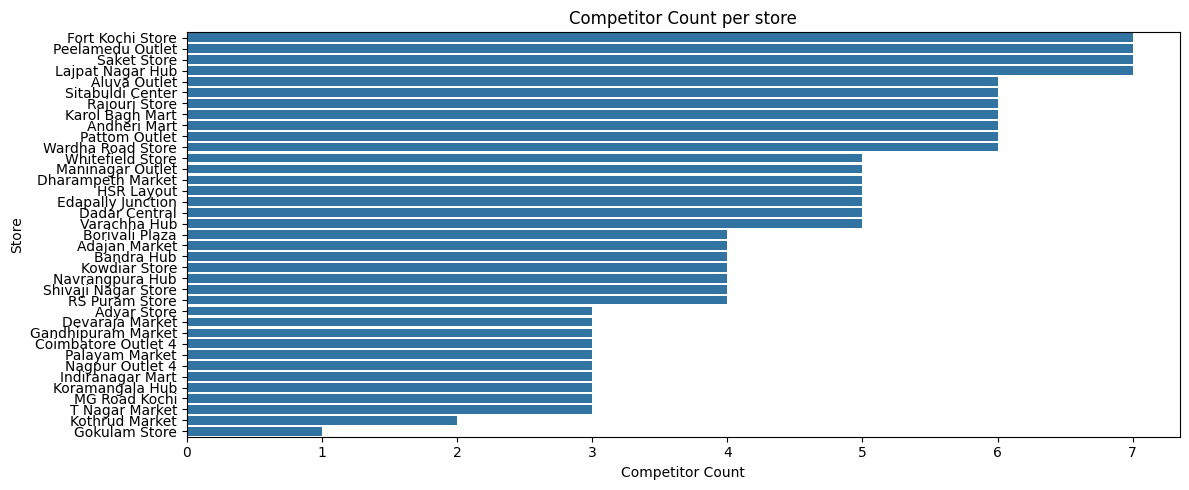

In [38]:
# Competition Analysis
competitor_count = stores_df.groupby('store')['local_competitor_count'].sum().reset_index().sort_values(by = 'local_competitor_count', ascending = False)

fig = plot_bar_chart(
    df = competitor_count,
    x_col = "store",
    y_col = "local_competitor_count",
    title = "Competitor Count per store",
    x_label = "Store",
    y_label = "Competitor Count",
    x_tick_rotation = 45,
    horizontal = True
)

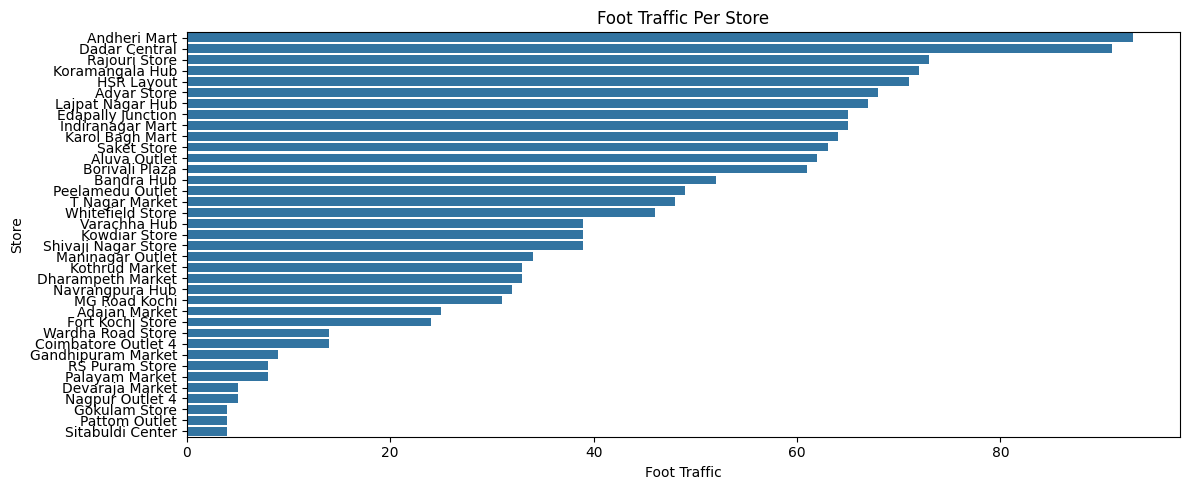

In [39]:
# Footfall Analysis
foot_traffic_index = stores_df.groupby('store')['foot_traffic_index'].sum().reset_index().sort_values(by = 'foot_traffic_index', ascending= False)

fig = plot_bar_chart(
    df = foot_traffic_index,
    x_col = 'store',
    y_col = 'foot_traffic_index',
    x_label = "Store",
    y_label = "Foot Traffic",
    title = "Foot Traffic Per Store",
    horizontal = True
)

## 4. Sales Data Analysis

In [40]:
store_size_and_sales = sales_df[['store_size_sqft', 'sales']]

In [41]:
store_size_and_sales[['store_size_sqft', 'sales']].corr()

,store_size_sqft,sales
store_size_sqft,1.00000,0.12449
sales,0.12449,1.00000


In [42]:
store_size_and_sales = sales_df.groupby(['store_id', 'store_size_sqft'])['sales'].sum().reset_index()

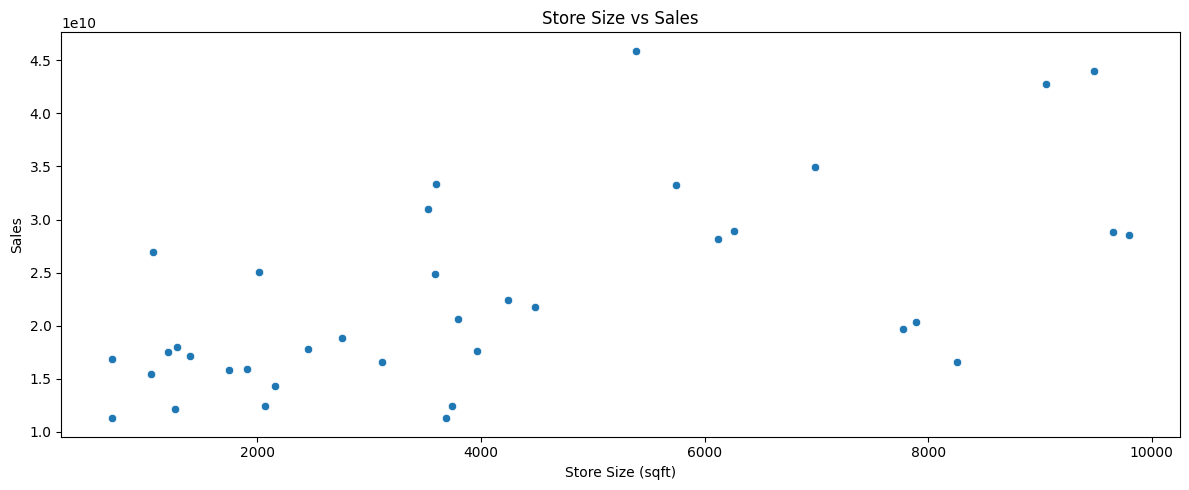

In [43]:
from helper_functions import plot_scatter_plot
fig = plot_scatter_plot(
    df = store_size_and_sales,
    x_col = "store_size_sqft",
    y_col = "sales",
    x_label = "Store Size (sqft)",
    y_label = "Sales",
    title = "Store Size vs Sales"
)

OBSERVATION: Moderate positive correlation exists between these two variables

In [44]:
store_size_vs_demand = sales_df.groupby(['store_id', 'store_size_sqft'])['demand'].sum().reset_index()

In [45]:
store_size_vs_demand[['store_size_sqft', 'demand']].corr()

,store_size_sqft,demand
store_size_sqft,1.000000,0.522832
demand,0.522832,1.000000


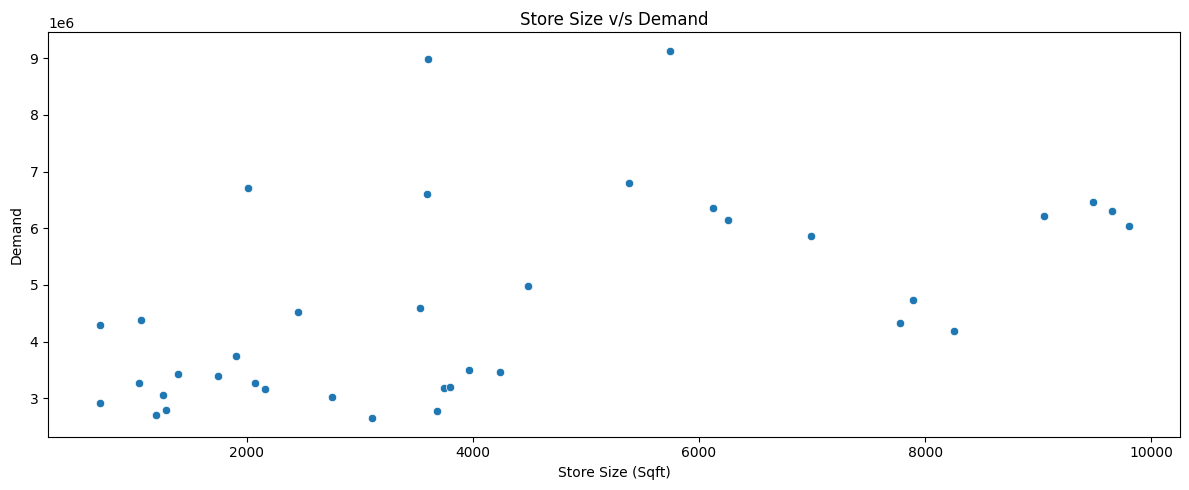

In [46]:
fig = plot_scatter_plot(
    df = store_size_vs_demand,
    x_col = "store_size_sqft",
    y_col = "demand",
    title = "Store Size v/s Demand",
    x_label = "Store Size (Sqft)",
    y_label = "Demand"
)

OBSERVATION: Moderate positive correlation exists between store size & demand

In [47]:
store_size_vs_inventory = (
    sales_df
    .groupby(['store_id', 'store_size_sqft'])
    ['inventory']
    .mean()
    .reset_index()
)

In [48]:
store_size_vs_inventory[['store_size_sqft', 'inventory']].corr()

,store_size_sqft,inventory
store_size_sqft,1.000000,0.460977
inventory,0.460977,1.000000


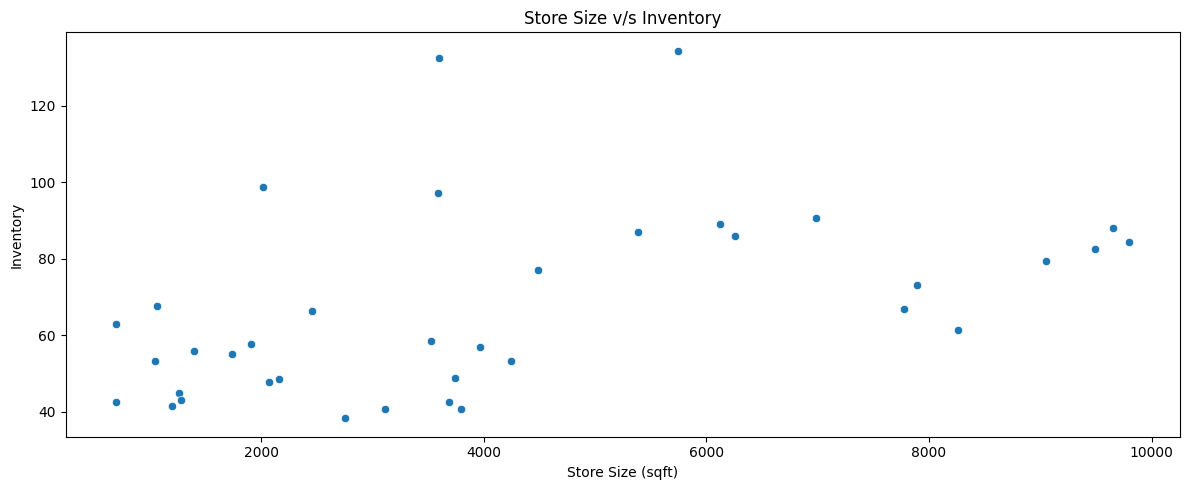

In [49]:
fig = plot_scatter_plot(
    df = store_size_vs_inventory,
    x_col = "store_size_sqft",
    y_col = "inventory",
    x_label = "Store Size (sqft)",
    y_label = "Inventory",
    title = "Store Size v/s Inventory"
)

OBSERVATION: Weak positive correlation

1. Are higher sqft stores making more revenue? <br>
2. Store Size vs Revenue <br>
3. Store Size vs Demand <br>
4. Store Size vs Inventory <br>
5. Does higher competition reduce sales ? <br>
6. Does foot traffic correlate with Demand ? <br>
7. Do mall stores outperform street stores? <br>
8. Do mall stores carry more inventory ? <br>
9. Does parking increase sales ? <br>
10. Is parking more important for Electronics? <br>
11. Do old stores perform better? <br>
12. Do mature stores have larger customer bases? <br>
13. Do pickup-enabled storesd perform better? <br>
14. Does online pickup reduce stockouts? <br>
15. Which area type generates highest sales? <br>
16. Do premium stores sell more Electronics? <br>
17. Do premium stores have larger basket sizes> <br>
18. What categories perform best in student areas? <br>
19. Is demand more price-sensitive? <br>
20. Do office districts generate weekday demand? <br>
21. Is weekend demand weaker? <br>
22. Which stores have highest spending customers? <br>
23. Which regions have highest purchasing power? <br>
24. Which stores are hardest to replenish? <br>
25. Which regions have longest lead times? <br>
26. Which stores need larger safety stock? <br>
27. Which stores are vulnerable to stockouts? <br>
28. Store Scoring Model <br>
&nbsp;&nbsp; Store Score = 30% Revenue + 20% Demand + 20% Foot Traffic + 15% Basket Size + 15% Inventory Efficiency
29. Store Clustering <br>
 Using:
* store_size_sqft <br>
* foot_traffic_index <br>
* avg_basket_size <br>
* competitor_count <br>
* lead_time